Calculating fractal geometry...
Fractal saved as 'mandelbrot_set_test.png'


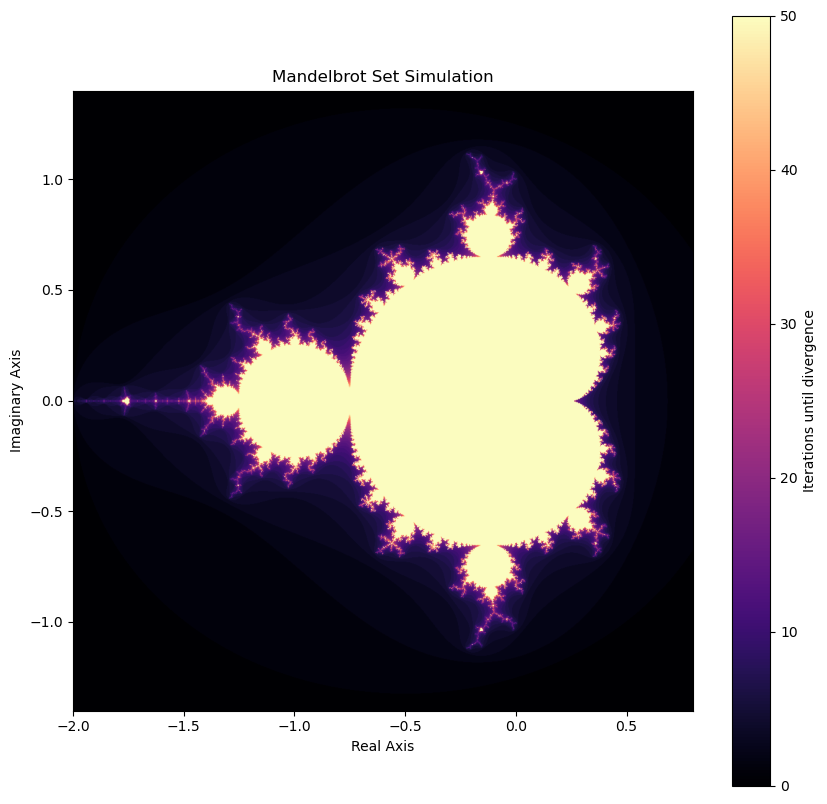

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_mandelbrot(h, w, max_iter=50):
    """
    h: height of image
    w: width of image
    max_iter: precision of the fractal
    """
    # Create a grid of complex numbers
    y, x = np.ogrid[-1.4:1.4:h*1j, -2:0.8:w*1j]
    c = x + y*1j
    
    # Initialize z to zero
    z = c
    # Keep track of which points have 'escaped' (gone to infinity)
    div_time = max_iter + np.zeros(z.shape, dtype=int)

    for i in range(max_iter):
        z = z**2 + c
        diverge = z*np.conj(z) > 2**2            # Check if magnitude > 2
        escaping = diverge & (div_time == max_iter) # Find points escaping NOW
        div_time[escaping] = i                  # Record the time they escaped
        z[diverge] = 2                          # Keep numbers small to avoid crash

    return div_time

# Run simulation
print("Calculating fractal geometry...")
fractal_data = simulate_mandelbrot(1000, 1000)

# Plotting
plt.figure(figsize=(10, 10))
plt.imshow(fractal_data, cmap='magma', extent=[-2, 0.8, -1.4, 1.4])
plt.colorbar(label='Iterations until divergence')
plt.title("Mandelbrot Set Simulation")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")

# Save for your Ubuntu Server
plt.savefig('mandelbrot_set_test.png')
print("Fractal saved as 'mandelbrot_set_test.png'")